In [32]:
# %% [markdown]
# # CMAPSS FD001 – LSTM with Keras
# 
# - Loads CMAPSS via step1_ml_pipeline
# - Builds sliding windows per engine
# - Trains an LSTM for RUL regression
# - Reports MAE / RMSE / R²

# %%
%pip install tensorflow --quiet

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from step1_ml_pipeline import load_cmapss_data, data_processing

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# %% 
# Load and standardize CMAPSS using your existing pipeline
dataname = "FD001"

train_df_raw, test_df_raw = load_cmapss_data(dataname)
train_std, test_std, scaler = data_processing(train_df_raw, test_df_raw)

print(train_std.head())
print(test_std.head())

print("Columns:", list(train_std.columns))


   engine_id  cycle  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  \
0          1      1       0.0 -1.214815 -0.049261 -0.610086       0.0   
1          1      2       0.0 -0.725926  0.211823 -0.401804       0.0   
2          1      3       0.0 -0.429630 -0.259852 -0.314883       0.0   
3          1      4       0.0 -0.429630 -0.900246 -0.505945       0.0   
4          1      5       0.0 -0.400000 -0.892857 -0.149241       0.0   

   sensor_6  sensor_7  sensor_8  ...  sensor_13  sensor_14  sensor_15  \
0       0.0  0.766667 -0.333333  ...       -0.7  -0.127448  -0.382643   
1       0.0  0.258333 -0.555556  ...       -0.2  -0.600730  -0.140039   
2       0.0  0.683333 -0.111111  ...       -0.6  -0.485231  -0.416174   
3       0.0  0.841667  0.222222  ...       -0.1  -0.445403  -1.394477   
4       0.0  0.466667 -0.333333  ...       -0.5  -0.447395  -0.187377   

   sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  RUL  
0        0.0       -0.5        0.0        0.0  

In [34]:
# %%
# Columns to use as features (drop id / target)
exclude = ["engine_id", "cycle", "RUL"]
feature_cols = [c for c in train_std.columns if c not in exclude]
n_features = len(feature_cols)
print("Num features:", n_features)

# Split engines: some engines for training, some for validation
val_frac = 0.15
rng = np.random.default_rng(seed=42)

eng_ids = train_std["engine_id"].unique()
rng.shuffle(eng_ids)

cut = int((1.0 - val_frac) * len(eng_ids))
val_ids = set(eng_ids[cut:])

mask_val = train_std["engine_id"].isin(val_ids)

train_df = train_std[~mask_val].copy()
val_df   = train_std[mask_val].copy()
test_df  = test_std.copy()

print(f"# train engines: {train_df['engine_id'].nunique()}")
print(f"#  val  engines: {val_df['engine_id'].nunique()}")
print(f"# test engines:  {test_df['engine_id'].nunique()}")


Num features: 21
# train engines: 85
#  val  engines: 15
# test engines:  100


## Apply PCA for Feature Reduction

We'll apply PCA to reduce dimensionality while preserving 95% variance. This should:
- Speed up training
- Reduce overfitting risk
- Remove noise from correlated sensors

In [ ]:
from sklearn.decomposition import PCA, KernelPCA

# Apply PCA to reduce features while preserving variance
APPLY_PCA = True  # Set to False to skip PCA
USE_KERNEL_PCA = True  # Set to True for RBF kernel PCA, False for linear PCA
N_COMPONENTS = 10  # Target number of components (for Kernel PCA)
VARIANCE_THRESHOLD = 0.95  # For linear PCA only

if APPLY_PCA:
    print("\n=== Applying PCA for feature reduction ===")
    
    # Fit PCA on training data only
    X_train_features = train_df[feature_cols].values
    
    if USE_KERNEL_PCA:
        print("Using Kernel PCA with RBF kernel")
        # Kernel PCA doesn't have explained_variance_ratio_ like linear PCA
        # So we specify n_components directly
        pca = KernelPCA(
            n_components=N_COMPONENTS,
            kernel='rbf',
            gamma=None,  # Auto: 1 / (n_features * X.var())
            fit_inverse_transform=False,
            random_state=42
        )
        pca.fit(X_train_features)
        n_components = N_COMPONENTS
        
        # Kernel PCA has eigenvalues (lambdas)
        if hasattr(pca, 'eigenvalues_') and pca.eigenvalues_ is not None:
            total_var = np.sum(pca.eigenvalues_)
            explained_var = np.sum(pca.eigenvalues_[:n_components]) / total_var
            print(f"Approximate variance explained: {explained_var:.2%}")
        else:
            print("Variance explained not available for Kernel PCA")
    else:
        print("Using Linear PCA")
        pca = PCA(n_components=VARIANCE_THRESHOLD, random_state=42)
        pca.fit(X_train_features)
        n_components = pca.n_components_
        explained_var = np.sum(pca.explained_variance_ratio_)
        print(f"Explained variance: {explained_var:.2%}")
    
    print(f"Original features: {len(feature_cols)}")
    print(f"PCA components: {n_components}")
    print(f"Reduction: {len(feature_cols) - n_components} features removed")
    
    # Transform all datasets
    train_pca = pca.transform(train_df[feature_cols].values)
    val_pca = pca.transform(val_df[feature_cols].values)
    test_pca = pca.transform(test_df[feature_cols].values)
    
    # Create new feature columns for PCA components
    pca_cols = [f"PC{i+1}" for i in range(n_components)]
    
    # Add PCA features to dataframes
    for i, col in enumerate(pca_cols):
        train_df[col] = train_pca[:, i]
        val_df[col] = val_pca[:, i]
        test_df[col] = test_pca[:, i]
    
    # Update feature_cols to use PCA components
    feature_cols = pca_cols
    n_features = len(feature_cols)
    
    print(f"Updated n_features: {n_features}")
else:
    print("PCA skipped - using original features")


=== Applying PCA for feature reduction ===
Original features: 21
PCA components: 9
Explained variance: 95.64%
Reduction: 12 features removed
Updated n_features: 9


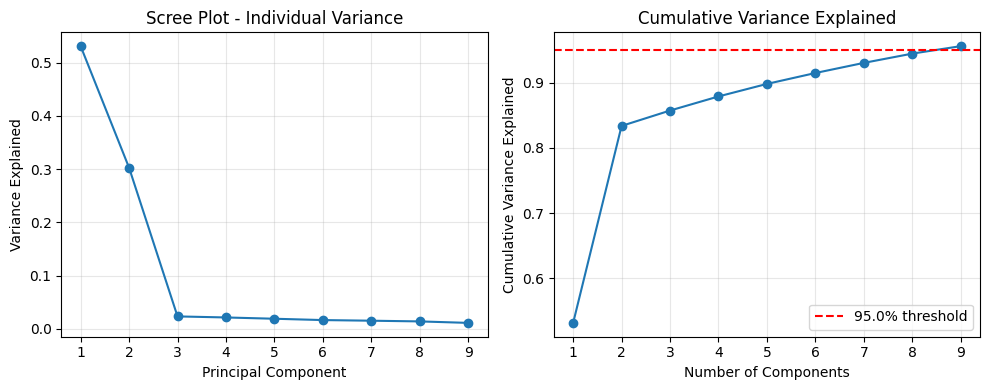

In [ ]:
# Visualize PCA variance explained
if APPLY_PCA and not USE_KERNEL_PCA:
    # Only plot for linear PCA (has explained_variance_ratio_)
    plt.figure(figsize=(10, 4))
    
    # Subplot 1: Scree plot
    plt.subplot(1, 2, 1)
    plt.plot(range(1, n_components + 1), pca.explained_variance_ratio_, 'o-')
    plt.xlabel('Principal Component')
    plt.ylabel('Variance Explained')
    plt.title('Scree Plot - Individual Variance')
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Cumulative variance
    plt.subplot(1, 2, 2)
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    plt.plot(range(1, n_components + 1), cumsum, 'o-')
    plt.axhline(y=VARIANCE_THRESHOLD, color='r', linestyle='--', label=f'{VARIANCE_THRESHOLD*100}% threshold')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Variance Explained')
    plt.title('Cumulative Variance Explained')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
elif APPLY_PCA and USE_KERNEL_PCA:
    # For Kernel PCA, plot eigenvalues if available
    if hasattr(pca, 'eigenvalues_') and pca.eigenvalues_ is not None:
        plt.figure(figsize=(10, 4))
        
        # Subplot 1: Eigenvalues
        plt.subplot(1, 2, 1)
        plt.plot(range(1, len(pca.eigenvalues_) + 1), pca.eigenvalues_, 'o-')
        plt.xlabel('Component')
        plt.ylabel('Eigenvalue')
        plt.title('Kernel PCA Eigenvalues')
        plt.grid(True, alpha=0.3)
        
        # Subplot 2: Cumulative eigenvalue proportion
        plt.subplot(1, 2, 2)
        cumsum = np.cumsum(pca.eigenvalues_) / np.sum(pca.eigenvalues_)
        plt.plot(range(1, len(cumsum) + 1), cumsum, 'o-')
        plt.axvline(x=n_components, color='r', linestyle='--', label=f'{n_components} components used')
        plt.xlabel('Number of Components')
        plt.ylabel('Cumulative Eigenvalue Proportion')
        plt.title('Kernel PCA Cumulative Variance')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("Eigenvalue visualization not available for this Kernel PCA configuration")

In [37]:
def make_windows(df, feature_cols, window_size, return_meta=False):
    X_list, y_list = [], []
    eng_list, cycle_list = [], []

    for eng_id, eng_df in df.groupby("engine_id"):
        eng_df = eng_df.sort_values("cycle")
        feats = eng_df[feature_cols].to_numpy()
        rul   = eng_df["RUL"].to_numpy()
        cycles = eng_df["cycle"].to_numpy()

        if len(eng_df) < window_size:
            continue

        for start in range(0, len(eng_df) - window_size + 1):
            end = start + window_size
            X_seq = feats[start:end, :]
            y_val = rul[end - 1]
            cyc   = cycles[end - 1]

            X_list.append(X_seq)
            y_list.append(y_val)

            if return_meta:
                eng_list.append(eng_id)
                cycle_list.append(cyc)

    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype=float)

    if return_meta:
        return X, y, np.array(eng_list), np.array(cycle_list)
    else:
        return X, y

window_size = 30
print("Making sliding windows with window_size =", window_size)

X_tr, y_tr = make_windows(train_df, feature_cols, window_size)
X_val, y_val = make_windows(val_df, feature_cols, window_size)
X_te, y_te, eng_te, cyc_te = make_windows(test_df, feature_cols, window_size, return_meta=True)


print("X_tr:", X_tr.shape, "y_tr:", y_tr.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_te:", X_te.shape, "y_te:", y_te.shape)


Making sliding windows with window_size = 30
X_tr: (15102, 30, 9) y_tr: (15102,)
X_val: (2629, 30, 9) y_val: (2629,)
X_te: (10196, 30, 9) y_te: (10196,)


In [55]:
#  LSTM without attention
import tensorflow as tf
from tensorflow import keras

input_shape = (window_size, n_features)
inputs = keras.Input(shape=input_shape)

x = keras.layers.LSTM(
    128,
    return_sequences=True,
    dropout=0.2,
    # recurrent_dropout=0.2
)(inputs)

x = keras.layers.LSTM(
    64,
    return_sequences=False,
    dropout=0.2,
    # recurrent_dropout=0.2
)(x)

h = keras.layers.Dense(64, activation="relu")(x)
outputs = keras.layers.Dense(1)(h)

model = keras.Model(inputs=inputs, outputs=outputs)


# 2) Dense + output
h = keras.layers.Dense(64, activation="relu")(x)
outputs = keras.layers.Dense(1)(h)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 30, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 30, 128)        │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,289 (485.50 KB)

 Trainable params: 124,289 (485.50 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# %%  (new cell – after model = keras.Model(...) )
import tensorflow as tf
from tensorflow import keras

def nasa_score_metric(y_true, y_pred):
    # y_true, y_pred shape: (batch, 1)
    d = y_pred - y_true
    s = tf.where(
        d < 0.0,
        tf.exp(-d / 13.0) - 1.0,   # early predictions (pessimistic)
        tf.exp(d / 10.0) - 1.0     # late predictions (over-optimistic)
    )
    # mean per batch, good for logging
    return tf.reduce_mean(s)


In [57]:
loss_fn = keras.losses.Huber(delta=10.0)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE"),
        nasa_score_metric      # <- our custom metric
    ]
)


early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

In [58]:
# %%
batch_size = 512
epochs = 80

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop, reduce_lr],
    verbose=2,
)


Epoch 1/80
30/30 - 5s - 165ms/step - MAE: 90.9554 - loss: 861.1370 - nasa_score_metric: 109013544.0000 - val_MAE: 83.7972 - val_loss: 789.8625 - val_nasa_score_metric: 6389529.5000 - learning_rate: 0.0010
Epoch 2/80
30/30 - 5s - 165ms/step - MAE: 90.9554 - loss: 861.1370 - nasa_score_metric: 109013544.0000 - val_MAE: 83.7972 - val_loss: 789.8625 - val_nasa_score_metric: 6389529.5000 - learning_rate: 0.0010
Epoch 2/80
30/30 - 3s - 109ms/step - MAE: 81.3225 - loss: 765.1015 - nasa_score_metric: 53001236.0000 - val_MAE: 73.4992 - val_loss: 687.0045 - val_nasa_score_metric: 2509859.7500 - learning_rate: 0.0010
Epoch 3/80
30/30 - 3s - 109ms/step - MAE: 81.3225 - loss: 765.1015 - nasa_score_metric: 53001236.0000 - val_MAE: 73.4992 - val_loss: 687.0045 - val_nasa_score_metric: 2509859.7500 - learning_rate: 0.0010
Epoch 3/80
30/30 - 4s - 119ms/step - MAE: 70.3537 - loss: 655.6068 - nasa_score_metric: 17429570.0000 - val_MAE: 61.9318 - val_loss: 571.9070 - val_nasa_score_metric: 879221.4375 - l

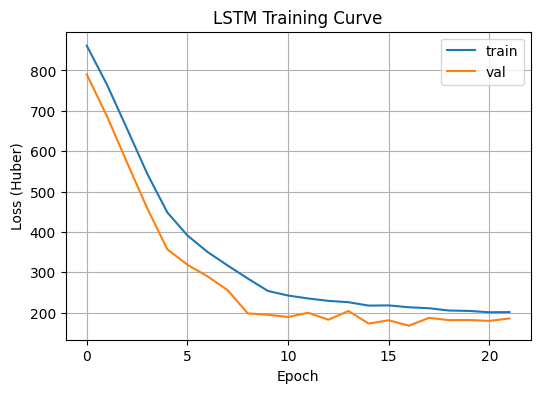

In [59]:
# %%
hist = history.history

plt.figure(figsize=(6,4))
plt.plot(hist["loss"], label="train")
plt.plot(hist["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss (Huber)")
plt.title("LSTM Training Curve")
plt.legend()
plt.grid(True)
plt.show()


In [60]:
# %%
y_pred = model.predict(X_te).ravel()

mae  = float(np.mean(np.abs(y_te - y_pred)))
rmse = float(np.sqrt(np.mean((y_te - y_pred)**2)))
ss_res = float(np.sum((y_te - y_pred)**2))
ss_tot = float(np.sum((y_te - np.mean(y_te))**2))
r2 = 1.0 - ss_res / ss_tot

def nasa_score_numpy(y_true, y_pred):
    d = y_pred - y_true
    s = np.where(d >= 0, np.exp(d / 13.0) - 1.0, np.exp(-d / 10.0) - 1.0)
    return float(np.sum(s))




nasa = nasa_score_numpy(y_te, y_pred)

print(f"Test MAE   = {mae:.2f}")
print(f"Test RMSE  = {rmse:.2f}")
print(f"Test R²    = {r2:.3f}")
print(f"NASA score = {nasa:.2f}")


319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
Test MAE   = 30.02
Test RMSE  = 42.28
Test R²    = 0.400
NASA score = 1616054295.68
Test MAE   = 30.02
Test RMSE  = 42.28
Test R²    = 0.400
NASA score = 1616054295.68


In [61]:
import numpy as np
from scipy.stats import weibull_min
from scipy.integrate import quad

# 1) Get failure cycles from df_train
failure_times = train_df.groupby("engine_id")["cycle"].max().values

# 2) Fit Weibull(k, lam)
k, loc, lam = weibull_min.fit(failure_times, floc=0)
print("k =", k, "  λ =", lam)

# 3) Weibull mean residual life
def weibull_RUL(cycle, k, lam):
    t = float(cycle)
    S = lambda u: np.exp(- (u / lam)**k)
    S_t = S(t)
    if S_t < 1e-12:
        return 0.0
    num, _ = quad(S, t, t + 5000)
    return num / S_t

# 4) Extract cycle from your windows (assuming cycle is feature 0)
test_cycles = np.array([window[-1, 0] for window in X_te])

y_pred_weibull = np.array([weibull_RUL(c, k, lam) for c in cyc_te])
nasa_weibull = nasa_score_numpy(y_te, y_pred_weibull)

print("Weibull NASA =", nasa_weibull)


k = 4.358267486977011   λ = 225.58064751777857
Weibull NASA = 109049211.8815842
Weibull NASA = 109049211.8815842


In [62]:

df_out = pd.DataFrame({
    "engine_id": eng_te,
    "cycle": cyc_te,
    "true_RUL": y_te,
    "pred_RUL_lstm": np.floor(y_pred),            # 向下取整
    "pred_RUL_weibull": np.floor(y_pred_weibull)  # 向下取整 (optional)
})


df_out.to_csv("rul_predictions_for_optimization.csv", index=False)
print("Saved rul_predictions_for_optimization.csv")


Saved rul_predictions_for_optimization.csv


If only consider the first prediction for each engine

In [63]:
import pandas as pd
import numpy as np

df_eval = pd.DataFrame({
    "engine_id": eng_te,
    "cycle": cyc_te,
    "true_RUL": y_te,
    "pred_RUL": y_pred,
})


In [64]:
df_eval_sorted = df_eval.sort_values(["engine_id", "cycle"])
df_first = df_eval_sorted.groupby("engine_id", as_index=False).first()


In [65]:
y_true_first = df_first["true_RUL"].values
y_pred_first = df_first["pred_RUL"].values

# RMSE
rmse_first = np.sqrt(np.mean((y_true_first - y_pred_first) ** 2))

# R^2
ss_res = np.sum((y_true_first - y_pred_first) ** 2)
ss_tot = np.sum((y_true_first - np.mean(y_true_first)) ** 2)
r2_first = 1.0 - ss_res / ss_tot

print(f"RMSE (one value per engine) = {rmse_first:.2f}")
print(f"R²   (one value per engine) = {r2_first:.3f}")


RMSE (one value per engine) = 58.09
R²   (one value per engine) = -0.757


Recovering the original dimension

In [66]:
y_pred = model.predict(X_te).ravel()


319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [67]:
import pandas as pd

df_win = pd.DataFrame({
    "engine_id": eng_te,
    "cycle": cyc_te,
    "true_RUL": y_te,
    "pred_LSTM": y_pred,
    "pred_weibull": y_pred_weibull
})

# 每台发动机只取最后一个 cycle（最大 cycle）
df_last = (
    df_win.sort_values(["engine_id", "cycle"])
          .groupby("engine_id")
          .tail(1)
          .reset_index(drop=True)
)


In [68]:
df_last["true_RUL"]      = np.floor(df_last["true_RUL"]).astype(int)
df_last["pred_LSTM"]     = np.floor(df_last["pred_LSTM"]).astype(int)
df_last["pred_weibull"]  = np.floor(df_last["pred_weibull"]).astype(int)


In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_final = mean_absolute_error(df_last["true_RUL"], df_last["pred_LSTM"])
rmse_final = mean_squared_error(df_last["true_RUL"], df_last["pred_LSTM"], squared=False)
r2_final = r2_score(df_last["true_RUL"], df_last["pred_LSTM"])


C:\Users\pyrpo\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [70]:
def nasa_score_numpy(y_true, y_pred):
    d = y_pred - y_true
    s = np.where(
        d >= 0,
        np.exp(d / 13.0) - 1.0,     
        np.exp(-d / 10.0) - 1.0     
    )
    return float(np.sum(s))

nasa_final = nasa_score_numpy(df_last["true_RUL"].values,
                              df_last["pred_LSTM"].values)


In [71]:
df_last.to_csv("final_test_results.csv", index=False)
print("Saved final_test_results.csv")

Saved final_test_results.csv
